In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [4]:
df=sns.load_dataset('tips')

In [24]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# First 5 rows of data

In [5]:
df.head()  

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [10]:
df.sex.value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [11]:
df["smoker"].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [12]:
df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [13]:
df.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

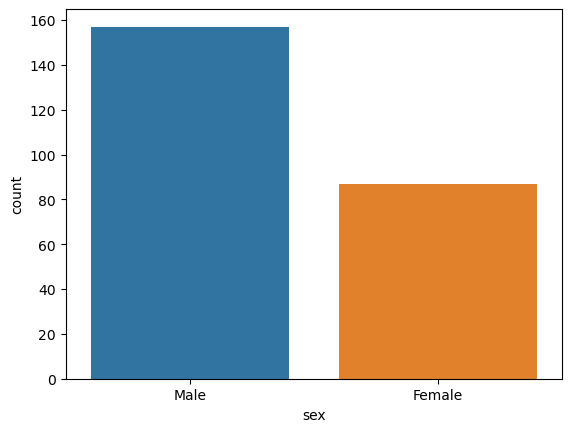

In [15]:
sns.countplot(df,x="sex")

*  From this plot we have observed that number of males are more than number of females

<Axes: xlabel='smoker', ylabel='count'>

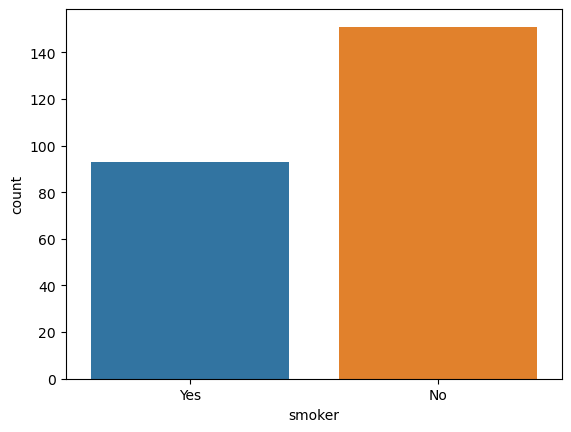

In [16]:
sns.countplot(df,x="smoker")

*  There are more non-smokers than smokers among the customers.



<Axes: xlabel='day', ylabel='count'>

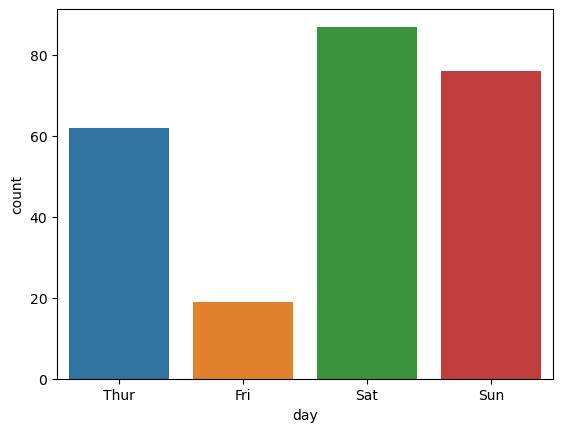

In [17]:
sns.countplot(df,x="day")

* Most observations are from saturay followed by sunday and Thursday , least on Friday

<Axes: xlabel='sex', ylabel='total_bill'>

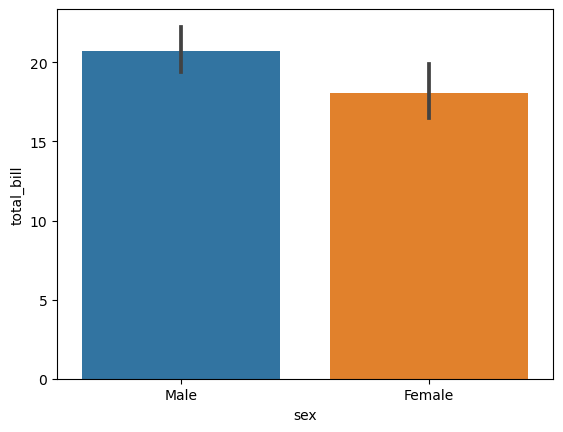

In [27]:
sns.barplot(df,x="sex",y="total_bill")

On average, male customers tend to have slightly higher total bills than female customers.

<Axes: xlabel='sex', ylabel='tip'>

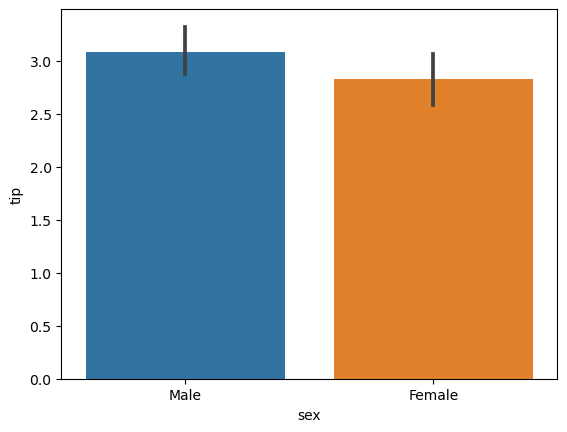

In [28]:
sns.barplot(df,x="sex",y="tip")

Saturday had the highest total tips, followed by Sunday, Thursday, and Friday.



In [41]:
df["daywise_tip"]=df.groupby("day")["tip"].transform("sum")

In [42]:
daywise_tip

day
Thur    171.83
Fri      51.96
Sat     260.40
Sun     247.39
Name: tip, dtype: float64

     I have created a new column which includes daywise tip and visualized it through barplot for better understanding

<Axes: xlabel='day', ylabel='daywise_tip'>

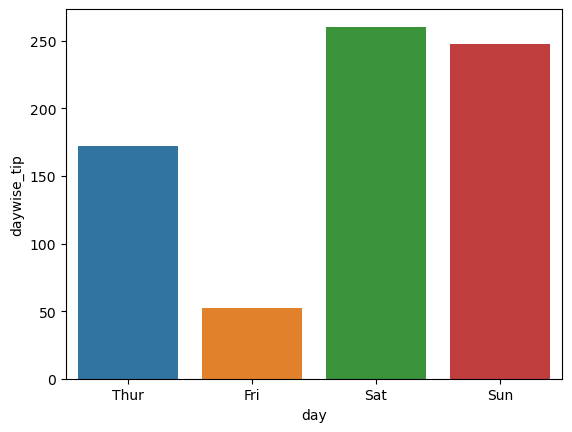

In [43]:
sns.barplot(df,x="day",y="daywise_tip")

     Saturday had the highest total tips, followed by Sunday, Thursday, and Friday.



<Axes: xlabel='total_bill', ylabel='tip'>

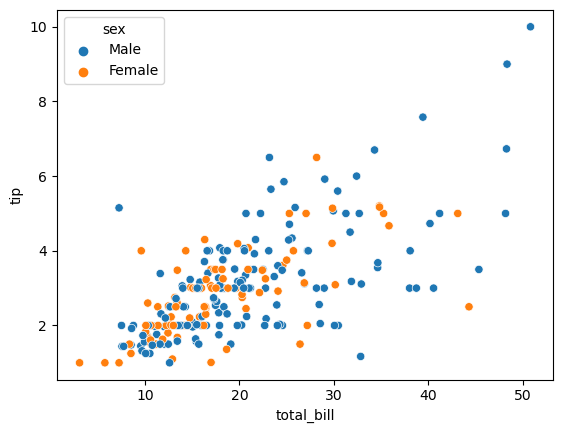

In [66]:
sns.scatterplot(df,x="total_bill",y="tip",hue="sex")

     There’s a positive correlation between total bill and tip. Both male and female customers follow this trend, though     males tend to give slightly higher tips for higher bills.

<Axes: xlabel='size', ylabel='tip'>

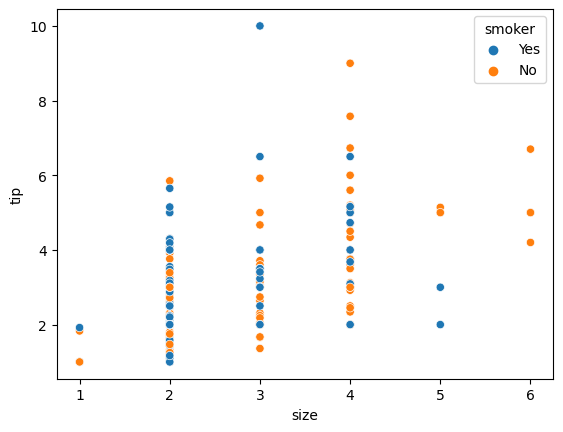

In [67]:
sns.scatterplot(df,x="size",y="tip",hue="smoker")

      Tip amounts generally increase with party size. There’s no strong distinction in tip behavior between smokers and non-smokers.

<Axes: xlabel='size', ylabel='total_bill'>

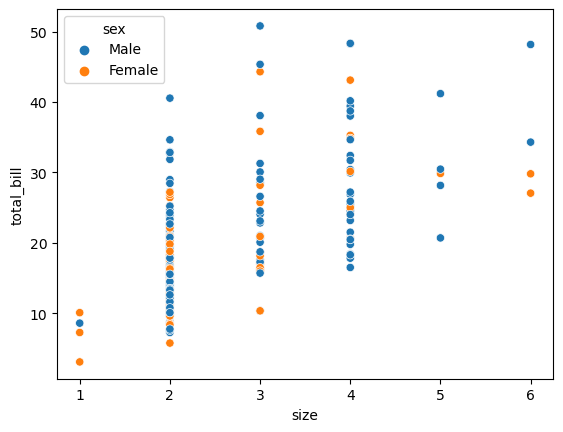

In [68]:
sns.scatterplot(df,x="size",y="total_bill",hue="sex")

     As the size of the group increases, the total bill tends to increase. No major difference is seen between sexes.

C:\Users\user\Desktop\Jup\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


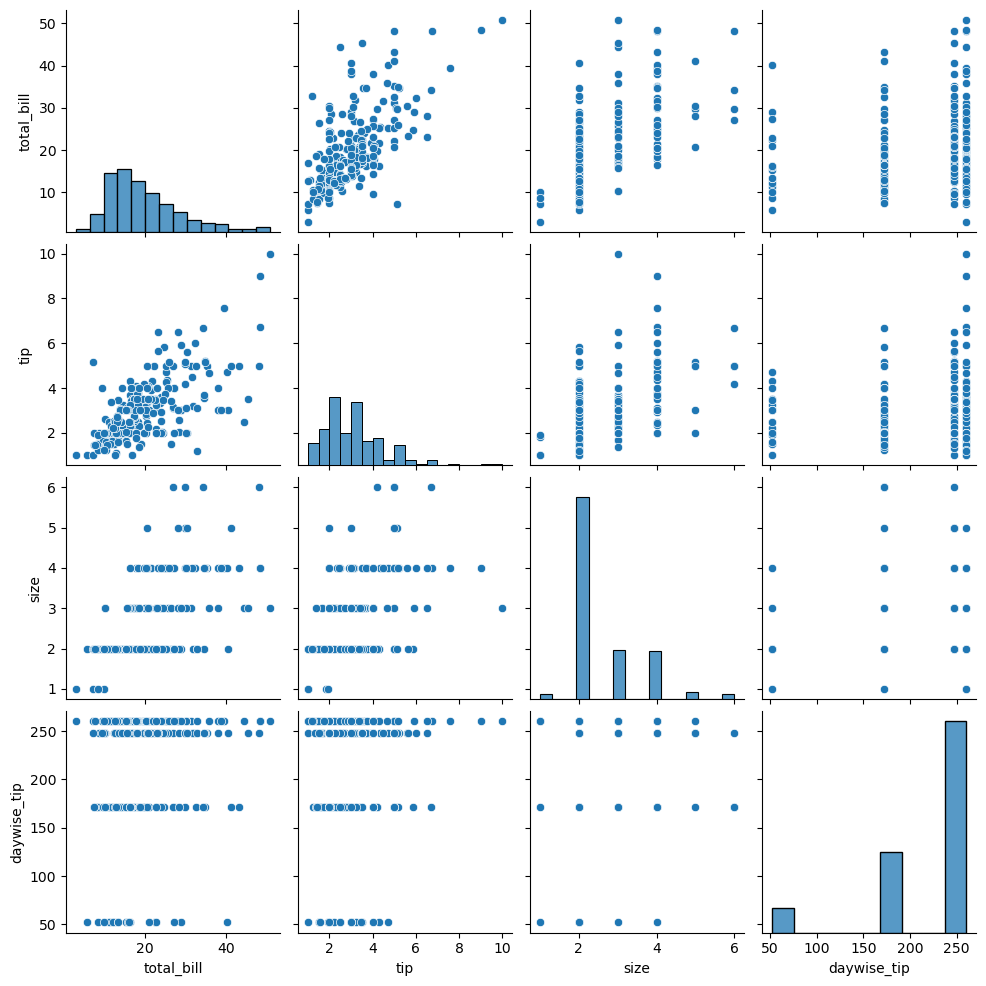

In [48]:
sns.pairplot(df)

     It shows pairwise relationships. total_bill and tip show strong positive correlation. Other variables show   scattered      relationships.

<Axes: xlabel='day', ylabel='total_bill'>

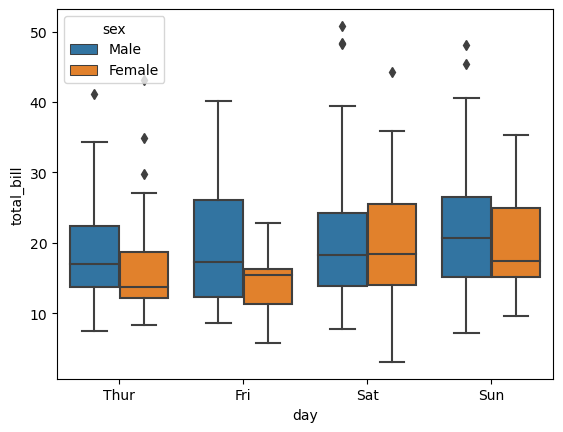

In [69]:
sns.boxplot(df,x="day",y="total_bill",hue="sex")

Saturday has the highest spread in total bills for both sexes. Bills on Thursday are generally lower and more consistent.

<Axes: xlabel='tip'>

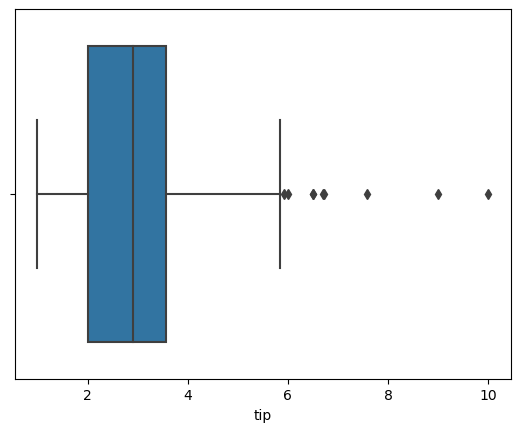

In [50]:
sns.boxplot(df,x="tip")

    Most tips range between $2 and $4. A few outliers give tips above $8 or $9.



<Axes: xlabel='size'>

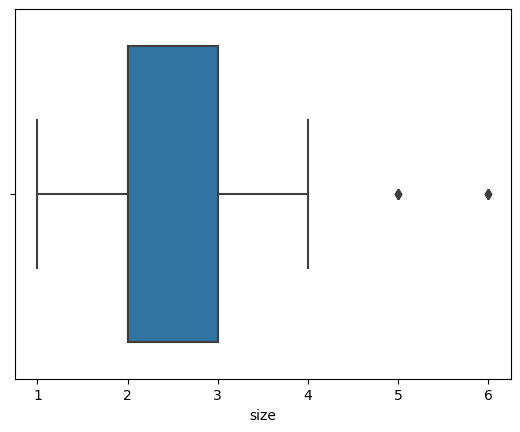

In [51]:
sns.boxplot(df,x="size")

    Majority of dining groups consist of 2 to 3 people, with a few larger groups up to 6.



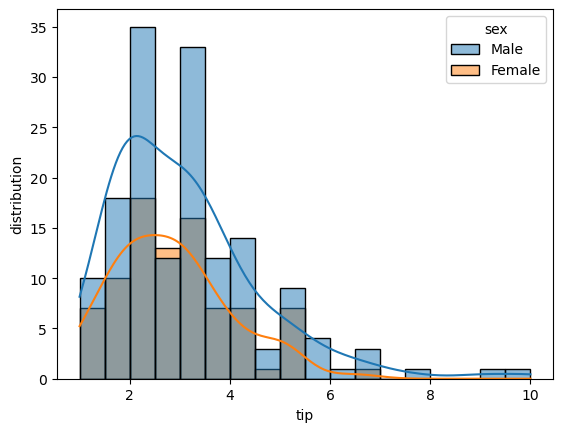

In [70]:
sns.histplot(df,x="tip",kde=True,hue="sex")
plt.xlabel("tip")
plt.ylabel("distribution")
plt.show()

      Tip distribution is right-skewed. Most tips are under $4. Males and females show similar distribution, but males      slightly dominate higher tip values

<Axes: xlabel='total_bill', ylabel='Count'>

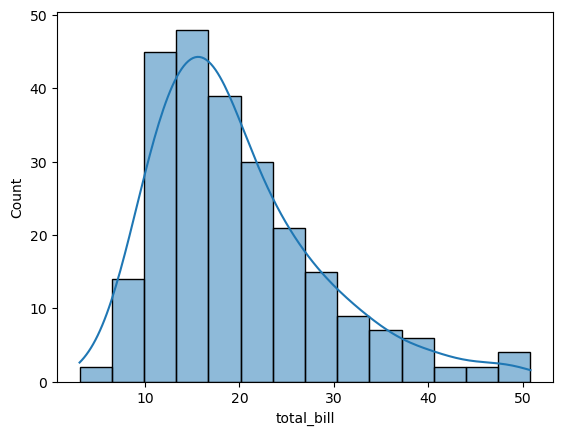

In [58]:
sns.histplot(df,x="total_bill",kde=True)

    Most total bills fall in the $10–$20 range. The distribution is right-skewed, with fewer very high bills.

# Grouped Heatmap

In [63]:
pivot=df.pivot_table(values="tip",index="day",columns="sex")

In [64]:
pivot

sex,Male,Female
day,,
Thur,2.980333,2.575625
Fri,2.693000,2.781111
Sat,3.083898,2.801786
Sun,3.220345,3.367222


     I created pivot table for total tip by Day and sexes, and shown visually through heatmap

<Axes: xlabel='sex', ylabel='day'>

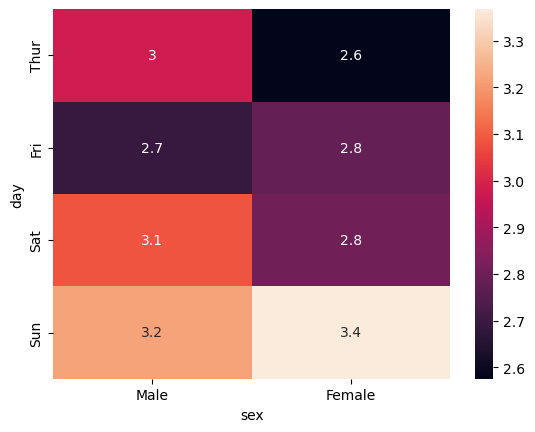

In [65]:
sns.heatmap(pivot,annot=True)

# Correlation

<Axes: >

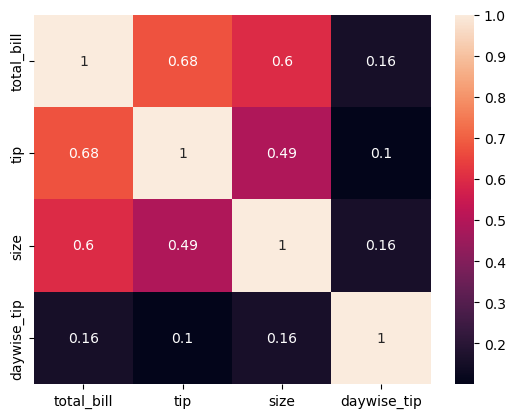

In [71]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

    We have observed that tip and total_bill having a strong and positive Correlation compared to other columns